In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path

## Load Data

In [3]:
DATA_DIR = Path("../data")

train = pd.read_csv(DATA_DIR/"train.csv")
test = pd.read_csv(DATA_DIR/"test.csv")
sample = pd.read_csv(DATA_DIR/"sample_submission.csv")

In [5]:
print(train.shape)
print(test.shape)
print(sample.shape)

(2000, 8)
(500, 7)
(500, 2)


In [6]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [9]:
print("Train Dataset Info:")
train.info()

print("\n\nTest Dataset Info:")
test.info()


Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64

There are not any missing values in the train and test dataset.

1 numerical column and 7 categorical columns in the train dataset.

In [ ]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

In [12]:
test.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

In [13]:
train.duplicated().sum()

np.int64(0)

In [14]:
train["prompt"].duplicated().sum()

np.int64(242)

In [28]:
train.duplicated(
    subset=["prompt", "A", "B", "C", "D", "E"]
).sum()

np.int64(183)

In [15]:
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

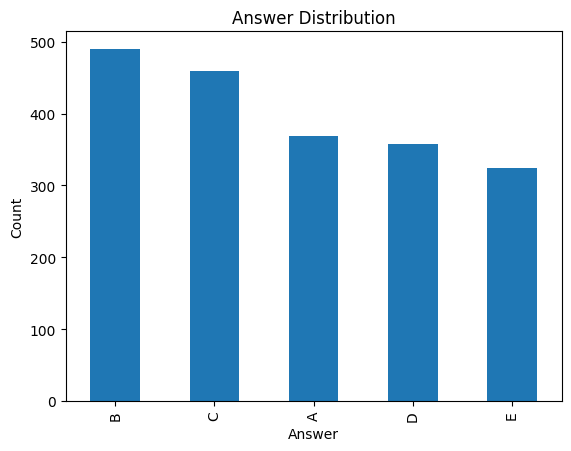

In [27]:
train["answer"].value_counts().plot(kind="bar")

plt.title("Answer Distribution")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.show()

In [17]:
train["prompt_length"] = train["prompt"].str.len()

In [18]:
train["prompt_length"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_length, dtype: float64

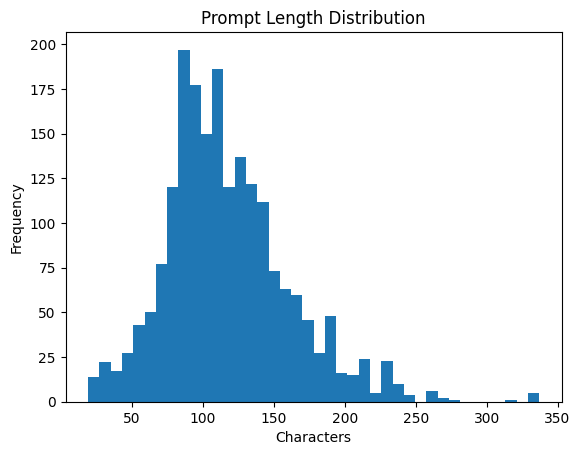

In [19]:
plt.hist(train["prompt_length"], bins=40)

plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Prompt Length Distribution")

plt.show()

In [20]:
for option in ["A", "B", "C", "D", "E"]:
    train[f"{option}_length"] = train[option].str.len()
    
train[
    ["A_length","B_length","C_length","D_length","E_length"]
].mean()

A_length    164.0915
B_length    166.6165
C_length    167.2270
D_length    162.5635
E_length    164.2300
dtype: float64

In [21]:
train.loc[
    train["prompt_length"].idxmax(),
    "prompt"
]

'Identify the correct statement: What is one of the examples of the models proposed by cosmologists and theoretical physicists without the cosmological or Copernican principles that can be used to address specific issues in the Lambda-CDM model and distinguish between current models and other possible models? based on the given context.'

In [22]:
train.loc[
    train["prompt_length"].idxmin(),
    "prompt"
]

'What is emissivity?'

In [23]:
print("Training samples :", len(train))
print("Testing samples  :", len(test))

print("Average prompt length:",
      train["prompt_length"].mean())

Training samples : 2000
Testing samples  : 500
Average prompt length: 117.6695
